In [7]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
import xml.etree.ElementTree as ET

def show_images_with_boxes(image_paths, label_paths=None, label_format='yolo', class_names=None, figsize=(12, 8)):
    """
    显示指定图片及其标注框

    参数:
        image_paths (list): 图片路径列表
        label_paths (list, optional): 标注文件路径列表，与图片一一对应。若为None，则自动根据图片路径推断（同名txt或xml）
        label_format (str): 'yolo' 或 'voc'，标注文件格式
        class_names (list, optional): 类别名称列表，用于在图上显示类别名
        figsize (tuple): 每张图显示时的画布大小
    """
    if label_paths is None:
        # 自动推断标注文件路径：同目录下同名 .txt（YOLO）或 .xml（VOC）
        label_paths = []
        for img_path in image_paths:
            p = Path(img_path)
            if label_format == 'yolo':
                label_path = p.with_suffix('.txt')
            else:
                label_path = p.with_suffix('.xml')
            if not label_path.exists():
                print(f"警告: 未找到标注文件 {label_path}")
                label_path = None
            label_paths.append(label_path)
    else:
        assert len(image_paths) == len(label_paths), "图片和标注文件数量不匹配"

    for idx, (img_path, lbl_path) in enumerate(zip(image_paths, label_paths)):
        if lbl_path is None or not Path(lbl_path).exists():
            print(f"跳过 {img_path}：标注文件不存在")
            continue

        # 读取图片
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"无法读取图片: {img_path}")
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        # 读取标注框
        boxes = []
        if label_format == 'yolo':
            # YOLO格式: class x_center y_center width height (归一化)
            with open(lbl_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls_id = int(parts[0])
                        xc, yc, bw, bh = map(float, parts[1:])
                        x1 = (xc - bw/2) * w
                        y1 = (yc - bh/2) * h
                        x2 = (xc + bw/2) * w
                        y2 = (yc + bh/2) * h
                        boxes.append((x1, y1, x2, y2, cls_id))
        else:  # voc
            tree = ET.parse(lbl_path)
            root = tree.getroot()
            # 图像尺寸优先从XML的size获取
            size = root.find('size')
            if size is not None:
                w = int(size.find('width').text)
                h = int(size.find('height').text)
            for obj in root.findall('object'):
                cls_name = obj.find('name').text
                # 如果提供了class_names，则转换为id；否则暂存名称
                cls_id = class_names.index(cls_name) if class_names and cls_name in class_names else cls_name
                bndbox = obj.find('bndbox')
                xmin = float(bndbox.find('xmin').text)
                ymin = float(bndbox.find('ymin').text)
                xmax = float(bndbox.find('xmax').text)
                ymax = float(bndbox.find('ymax').text)
                boxes.append((xmin, ymin, xmax, ymax, cls_id))

        # 绘图
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        ax.imshow(img)
        for (x1, y1, x2, y2, cls) in boxes:
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                     linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            # 添加标签文本
            if class_names is not None and isinstance(cls, int) and cls < len(class_names):
                label = class_names[cls]
            else:
                label = str(cls)
            ax.text(x1, y1-5, label, color='red', fontsize=10,
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        ax.axis('off')
        plt.tight_layout()
        plt.show()

项目根目录: D:\ShipTarget\ship_detection


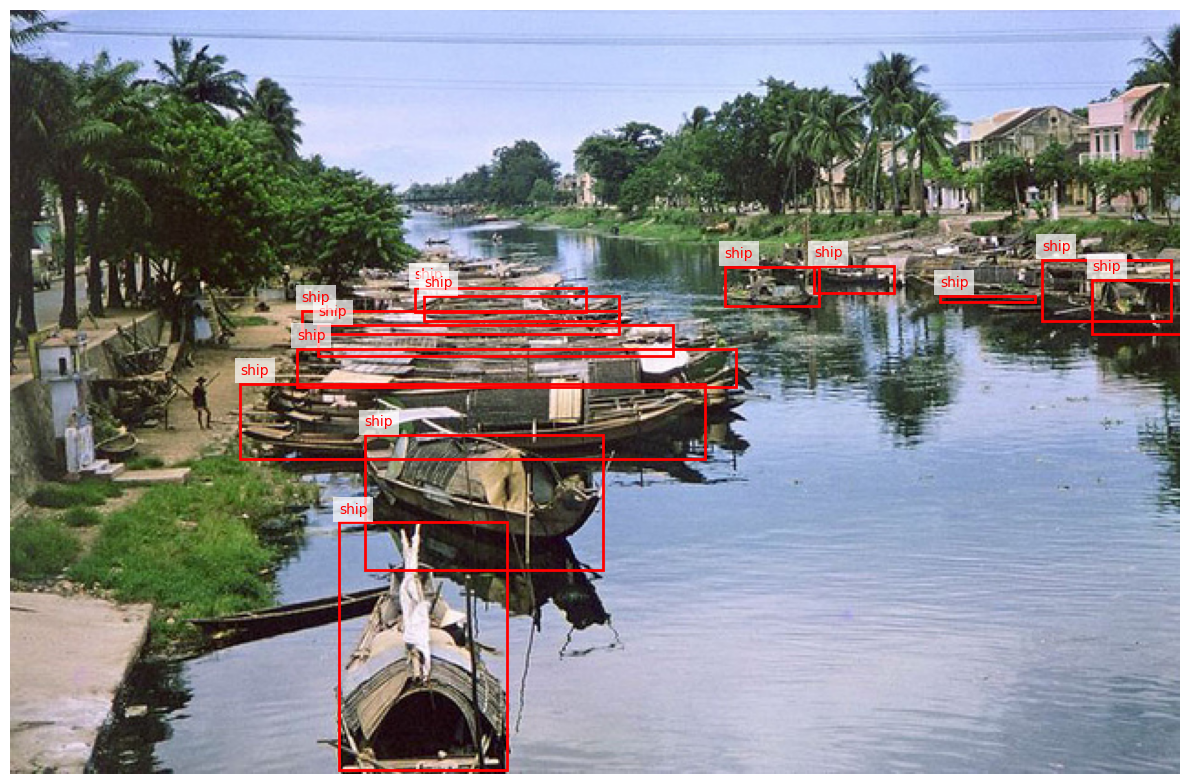

In [18]:
import os
from pathlib import Path
# 创建项目目录结构
# 获取当前脚本所在目录的绝对路径
current_dir = Path.cwd()  # 或者 Path(".").absolute()
project_root = current_dir / "ship_detection"
dataset_dir = project_root / "datasets" / "seaships"
models_dir = project_root / "models"
results_dir = project_root / "results"

print(f"项目根目录: {project_root}")

img_list = [
    dataset_dir / "images" / "test" / "000000059752.jpg",
]
lab_list = [
    dataset_dir / "labels" / "test" / "000000059752.txt",
]
# 自动推断同目录下同名txt文件
show_images_with_boxes(img_list, lab_list, label_format='yolo', class_names=['ship'])

In [25]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from pathlib import Path
import math
import xml.etree.ElementTree as ET

def show_grid_images_with_equal_height(image_paths, label_paths=None, label_format='yolo',
                                       class_names=None, base_height=5,
                                       max_cols=4, share_axes=False):
    """
    将多张图片以网格形式展示，所有子图高度一致（等长），宽度根据图片宽高比自适应。
    编号 (a)、(b) 等显示在图片下方。

    参数:
        image_paths (list): 图片路径列表
        label_paths (list, optional): 标注文件路径列表
        label_format (str): 'yolo' 或 'voc'
        class_names (list, optional): 类别名称列表
        base_height (float): 每行子图的基础高度（英寸）
        max_cols (int): 每行最多显示的子图数量
        share_axes (bool): 是否共享坐标轴
    """
    n = len(image_paths)
    if n == 0:
        print("没有图片需要显示")
        return

    # 按行分组（每行最多 max_cols 张）
    nrows = math.ceil(n / max_cols)
    rows = []
    for i in range(nrows):
        start = i * max_cols
        end = min(start + max_cols, n)
        rows.append(image_paths[start:end])

    # 计算每张图片的宽高比（宽度/高度）
    aspect_ratios = []
    for img_path in image_paths:
        img = cv2.imread(str(img_path))
        if img is None:
            aspect_ratios.append(1.0)  # 默认方形
        else:
            h, w = img.shape[:2]
            aspect_ratios.append(w / h)

    # 为每行计算每个子图的宽度（英寸），使得整行总宽度合理
    # 整体图幅宽度 = 每行子图宽度之和 + 子图间隙
    # 这里简化：每行内宽度比例等于宽高比，高度固定为 base_height
    fig_width = 0
    row_widths = []
    for row in rows:
        row_aspects = [aspect_ratios[image_paths.index(p)] for p in row]
        # 该行总宽度（英寸）= 高度 * 各图宽高比之和
        total_width = base_height * sum(row_aspects)
        row_widths.append(total_width)
        fig_width = max(fig_width, total_width)
    # 整体图幅高度 = 行数 * (base_height + 标题与编号空间)
    fig_height = nrows * (base_height + 0.5)  # 额外0.5英寸用于放置编号

    # 创建图幅，使用 GridSpec
    fig = plt.figure(figsize=(fig_width, fig_height))
    outer_gs = gridspec.GridSpec(nrows, 1, height_ratios=[base_height + 0.5] * nrows,
                                 hspace=0.3)  # 行间垂直间距

    # 自动推断标注文件路径
    if label_paths is None:
        label_paths = []
        for img_path in image_paths:
            p = Path(img_path)
            if label_format == 'yolo':
                lbl = p.with_suffix('.txt')
            else:
                lbl = p.with_suffix('.xml')
            label_paths.append(lbl if lbl.exists() else None)

    # 遍历每一行
    for row_idx, row_imgs in enumerate(rows):
        # 该行的子图数量
        ncols = len(row_imgs)
        row_aspects = [aspect_ratios[image_paths.index(p)] for p in row_imgs]
        # 该行内各子图的宽度比例（归一化）
        norm_ratios = [ar / sum(row_aspects) for ar in row_aspects]
        # 创建内层 GridSpec，宽度比例按 norm_ratios 分配
        inner_gs = gridspec.GridSpecFromSubplotSpec(1, ncols,
                                                    subplot_spec=outer_gs[row_idx],
                                                    width_ratios=norm_ratios,
                                                    wspace=0.05)

        for col_idx, img_path in enumerate(row_imgs):
            ax = plt.subplot(inner_gs[col_idx])
            lbl_path = label_paths[image_paths.index(img_path)]

            # 显示图片
            img = cv2.imread(str(img_path))
            if img is None:
                ax.text(0.5, 0.5, f"无法读取\n{Path(img_path).name}",
                        transform=ax.transAxes, ha='center', va='center')
                ax.axis('off')
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w = img.shape[:2]
            ax.imshow(img)

            # 读取标注框（同之前逻辑）
            boxes = []
            if lbl_path is not None and Path(lbl_path).exists():
                if label_format == 'yolo':
                    with open(lbl_path, 'r') as f:
                        for line in f:
                            parts = line.strip().split()
                            if len(parts) == 5:
                                cls_id = int(parts[0])
                                xc, yc, bw, bh = map(float, parts[1:])
                                x1 = (xc - bw/2) * w
                                y1 = (yc - bh/2) * h
                                x2 = (xc + bw/2) * w
                                y2 = (yc + bh/2) * h
                                boxes.append((x1, y1, x2, y2, cls_id))
                else:  # voc
                    tree = ET.parse(lbl_path)
                    root = tree.getroot()
                    size = root.find('size')
                    if size is not None:
                        w = int(size.find('width').text)
                        h = int(size.find('height').text)
                    for obj in root.findall('object'):
                        cls_name = obj.find('name').text
                        cls_id = class_names.index(cls_name) if class_names and cls_name in class_names else cls_name
                        bndbox = obj.find('bndbox')
                        xmin = float(bndbox.find('xmin').text)
                        ymin = float(bndbox.find('ymin').text)
                        xmax = float(bndbox.find('xmax').text)
                        ymax = float(bndbox.find('ymax').text)
                        boxes.append((xmin, ymin, xmax, ymax, cls_id))

            # 绘制边界框
            for (x1, y1, x2, y2, cls) in boxes:
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                         linewidth=1.5, edgecolor='r', facecolor='none')
                ax.add_patch(rect)
                if class_names is not None and isinstance(cls, int) and cls < len(class_names):
                    label = class_names[cls]
                else:
                    label = str(cls)
                ax.text(x1, y1-3, label, color='red', fontsize=8,
                        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

            # 添加编号（在图片下方）
            global_idx = image_paths.index(img_path)
            letter = chr(ord('a') + global_idx) if global_idx < 26 else f'({global_idx+1})'
            ax.text(0.5, -0.08, f'({letter})', transform=ax.transAxes,
                    ha='center', va='top', fontsize=10)
            ax.axis('off')

    plt.subplots_adjust(bottom=0.05, top=0.95)
    plt.show()

项目根目录: D:\ShipTarget\ship_detection


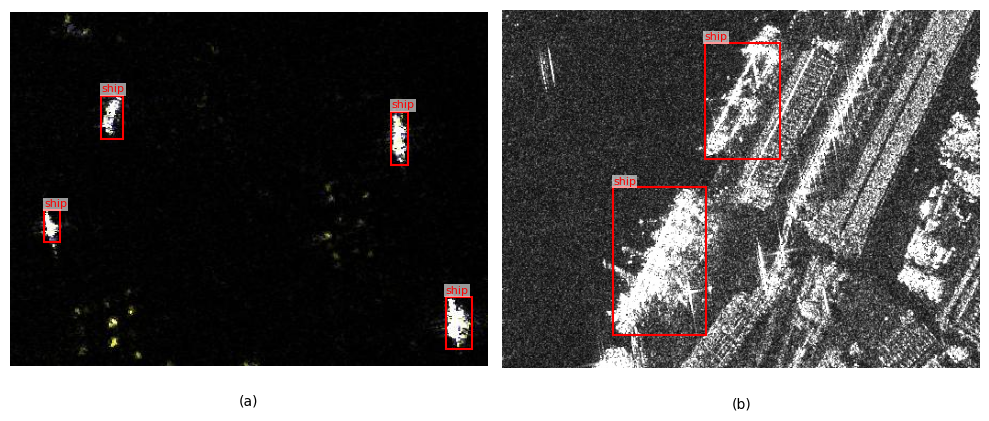

In [28]:
import os
from pathlib import Path
# 创建项目目录结构
# 获取当前脚本所在目录的绝对路径
current_dir = Path.cwd()  # 或者 Path(".").absolute()
project_root = current_dir / "ship_detection"
dataset_dir = project_root / "datasets" / "SSDD"
models_dir = project_root / "models"
results_dir = project_root / "results"

print(f"项目根目录: {project_root}")

img_list = [
    dataset_dir / "images" / "val" / "000061.jpg",
    dataset_dir / "images" / "val" / "000239.jpg",
]
lab_list = [
    dataset_dir / "labels" / "val" / "000061.txt",
    dataset_dir / "labels" / "val" / "000239.txt",
]
# 自动推断同目录下同名txt文件
show_grid_images_with_boxes(img_list, lab_list, label_format='yolo', class_names=['ship'], base_figsize=(5, 5), max_cols=3)